In [16]:
import matplotlib.pyplot as plt
import numpy as np
from amocatlas import read
from scipy.stats import linregress, t

from correlation_trends import (
    analysis,
    correlation,
    seasonal,
    trends
)

In [2]:
figpath = "../figures/"

In [3]:
## Read the datasets

# 26N transports: MOC, TRANS_FC, TRANS_EKMAN, TRANS_UMO
transports = read.rapid()

MOC = transports.MOC
#TRANS_FC = transports.TRANS_FC
TRANS_EKMAN = transports.TRANS_EKMAN
#TRANS_UMO = transports.TRANS_UMO

# 47N NOAC overturning (monthly): MOC_SIGMA0
# noac = read.read_47n()

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series



In [6]:
detrended_MOC = analysis.detrending(MOC, MOC["TIME"])
detrended_EKMAN = analysis.detrending(TRANS_EKMAN, TRANS_EKMAN["TIME"])
deseasonalized_MOC = seasonal.remove_seasonal_cycle(detrended_MOC)
deseasonalized_EKMAN = seasonal.remove_seasonal_cycle(detrended_EKMAN)

(0.0, 2000.0)

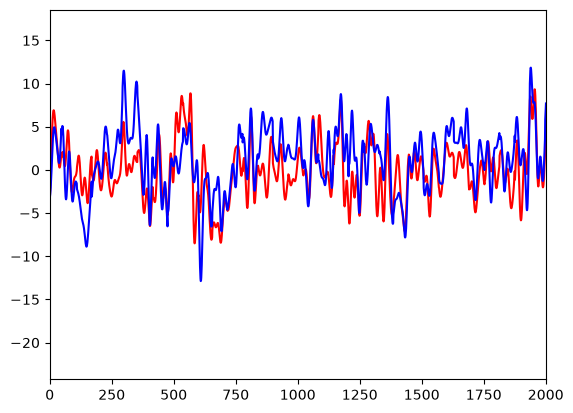

In [7]:
plt.plot(deseasonalized_EKMAN.values, color="red")
plt.plot(deseasonalized_MOC.values, color="blue")
plt.xlim(0, 2000)

In [8]:
raw_lags, raw_cc = correlation.cross_correlation(detrended_EKMAN, detrended_MOC)
raw_lag = raw_lags[raw_cc.argmax()] * 0.5
print(
    f"The Ekman component leads the Florida Current by {-raw_lag} days when including the seasonal cycle."
)

The Ekman component leads the Florida Current by 0.5 days when including the seasonal cycle.


In [9]:
lags, cc = correlation.cross_correlation(deseasonalized_EKMAN, deseasonalized_MOC)
lag = lags[cc.argmax()] * 0.5
print(
    f"The Ekman component leads the Florida Current by {-lag} days with the seasonal cycle removed"
)

The Ekman component leads the Florida Current by 0.5 days with the seasonal cycle removed


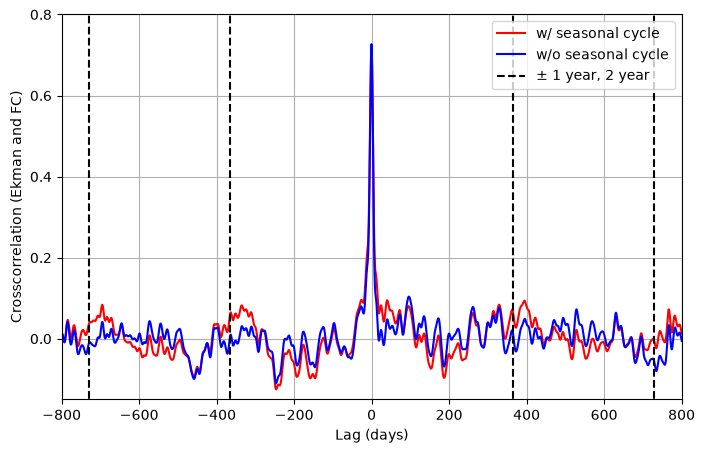

In [11]:
plt.figure(figsize=[8, 5])
plt.plot(raw_lags / 2, raw_cc, color="red", label="w/ seasonal cycle")
plt.plot(lags / 2, cc, color="blue", label="w/o seasonal cycle")
plt.xlim(-800, 800)
plt.vlines(
    [-365 * 2, -365, 365, 365 * 2],
    -1,
    1,
    color="k",
    ls="--",
    label="$\\pm$ 1 year, 2 year",
)
plt.ylim(-0.15, 0.8)
plt.grid()
plt.ylabel("Crosscorrelation (Ekman and FC)")
plt.xlabel("Lag (days)")
plt.legend()
plt.savefig(figpath + "crosscorrelation_EKMAN_MOC_seasonal.png")

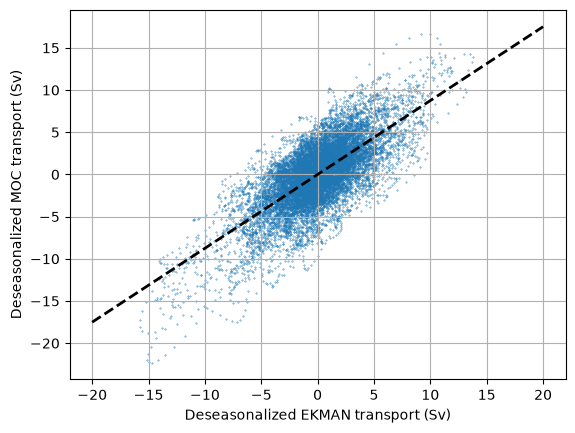

In [12]:
plt.scatter(deseasonalized_EKMAN[:-1], deseasonalized_MOC[1:], s=0.1)
lag_trend = linregress(deseasonalized_EKMAN[:-1], deseasonalized_MOC[1:])
plt.plot(
    np.linspace(-20, 20, 100),
    lag_trend.intercept + lag_trend.slope * np.linspace(-20, 20, 100),
    lw=2,
    ls="--",
    color="k",
)
plt.grid()
plt.xlabel("Deseasonalized EKMAN transport (Sv)")
plt.ylabel("Deseasonalized MOC transport (Sv)")
plt.savefig(figpath + "correlation_trend_EKMAN_MOC.png")

In [20]:
EDOF = np.min(
    np.array(
        [trends.effective_dof(deseasonalized_MOC[1:],dt = 0.5),
        trends.effective_dof(deseasonalized_EKMAN[:-1],dt = 0.5)]
    )
)
p_eff = 2 * t.sf(np.abs(lag_trend.slope / (lag_trend.stderr * np.sqrt(MOC.size / EDOF))), EDOF)
p_eff

np.float64(2.3934249652173714e-38)